## Lọc bỏ những ảnh bị lỗi

In [8]:
import shutil
import os

# Thư mục nguồn và đích
source_dir = '/kaggle/input/car-cs114/dataset'
target_dir = '/kaggle/working/car_image'

# Sao chép toàn bộ dataset
if not os.path.exists(target_dir):
    shutil.copytree(source_dir, target_dir)
    print(f"Dataset đã được sao chép tới: {target_dir}")
else:
    print("Dataset đã tồn tại ở thư mục làm việc.")
from PIL import Image

# Hàm kiểm tra tệp hình ảnh hợp lệ
def is_valid_image(file_path):
    try:
        img = Image.open(file_path)
        img.verify()  # Kiểm tra hình ảnh
        return True
    except (IOError, SyntaxError):
        return False

# Kiểm tra và xóa các tệp lỗi trong thư mục sao chép
for root, dirs, files in os.walk(target_dir):
    for file in files:
        file_path = os.path.join(root, file)
        if not is_valid_image(file_path):
            print(f"Loại bỏ tệp không hợp lệ: {file_path}")
            os.remove(file_path)


Dataset đã tồn tại ở thư mục làm việc.


## Thống kê và trực quan hóa dữ liệu

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Đường dẫn đến dataset
dataset_dir = '/kaggle/input/car-cs114/dataset'

# Thống kê số lượng ảnh trong từng nhãn
label_counts = {}
for label in os.listdir(dataset_dir):
    label_dir = os.path.join(dataset_dir, label)
    if os.path.isdir(label_dir):
        num_images = len(os.listdir(label_dir))
        label_counts[label] = num_images

# Vẽ biểu đồ phân phối số lượng ảnh trong mỗi nhãn
labels = list(label_counts.keys())
counts = list(label_counts.values())

plt.figure(figsize=(12, 6))
sns.barplot(x=labels, y=counts, palette="viridis")
plt.title("Phân phối số lượng ảnh trong từng nhãn")
plt.ylabel("Số lượng ảnh")
plt.xlabel("Nhãn")
plt.xticks(rotation=45)

# Hiển thị số lượng ảnh trên các cột
for i, count in enumerate(counts):
    plt.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# In tổng số lượng ảnh
total_images = sum(label_counts.values())
print(f"Tổng số lượng ảnh: {total_images} ảnh")


In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Số lượng ảnh cần hiển thị mỗi nhãn
images_per_label = 10

# Lấy danh sách các nhãn
labels = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])

# Kích thước ảnh hiển thị
img_size = (100, 100)

# Tạo grid plot
fig, axes = plt.subplots(len(labels), images_per_label + 1, figsize=(15, len(labels) * 1.5))
fig.tight_layout(pad=1.0)  # Giảm khoảng cách giữa các ảnh

# Duyệt qua từng nhãn và hiển thị ảnh
for i, label in enumerate(labels):
    label_dir = os.path.join(dataset_dir, label)
    images = sorted(os.listdir(label_dir))[:images_per_label]
    
    # Thêm tên nhãn ở cột đầu tiên
    axes[i, 0].text(0.5, 0.5, label, fontsize=14, va='center', ha='center')
    axes[i, 0].axis('off')
    
    # Hiển thị ảnh trong cùng hàng
    for j, img_name in enumerate(images):
        img_path = os.path.join(label_dir, img_name)
        img = Image.open(img_path).resize(img_size)
        axes[i, j + 1].imshow(img)
        axes[i, j + 1].axis('off')

plt.show()


## Gọi các thư viện và hàm cần thiết

In [9]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def lr_schedule(epoch, lr):
    if epoch % 7 == 0 and epoch != 0:  # Mỗi 5 epoch, giảm 10 lần
        return lr * 0.1
    return lr  # Giữ nguyên LR cho các epoch khác
 

## Xử lí và chia dữ liệu

In [10]:
# Cấu hình cơ bản
target_dir = "/kaggle/working/car_image"  # Thư mục chứa dữ liệu
img_height, img_width = 300, 300
batch_size = 32
num_classes = 9

# Chuẩn bị dữ liệu
train_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    target_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    target_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 30402 images belonging to 9 classes.
Found 7597 images belonging to 9 classes.


In [13]:
print("Thống kê dữ liệu:")
print(f"Số lượng ảnh trong tập train: {train_data.samples}")
print(f"Số lượng ảnh trong tập validation: {val_data.samples}")

print("\nSố lượng ảnh trong từng lớp (train):")
for class_name, count in zip(train_data.class_indices.keys(), train_data.class_indices.values()):
    print(f"  {class_name}: {train_data.labels.tolist().count(count)}")

print("\nSố lượng ảnh trong từng lớp (validation):")
for class_name, count in zip(val_data.class_indices.keys(), val_data.class_indices.values()):
    print(f"  {class_name}: {val_data.labels.tolist().count(count)}")


Thống kê dữ liệu:
Số lượng ảnh trong tập train: 30402
Số lượng ảnh trong tập validation: 7597

Số lượng ảnh trong từng lớp (train):
  Honda: 2623
  Hyundai: 3034
  KIA: 2814
  Mazda: 2747
  Mitsubishi: 2541
  Others: 3664
  Suzuki: 5552
  Toyota: 4954
  VinFast: 2473

Số lượng ảnh trong từng lớp (validation):
  Honda: 655
  Hyundai: 758
  KIA: 703
  Mazda: 686
  Mitsubishi: 635
  Others: 916
  Suzuki: 1388
  Toyota: 1238
  VinFast: 618


## Thêm và huấn luyện các top layers

In [ ]:
# Sử dụng EfficientNetB3
base_model = EfficientNetB3(include_top=False, weights='imagenet')
# Đóng băng các lớp của base_model
base_model.trainable = False

# Định nghĩa input
input_tensor = Input(shape=(300, 300, 3))
# Forward pass
x = base_model(input_tensor)
x = GlobalAveragePooling2D()(x)
output_tensor = Dense(num_classes, activation='softmax')(x)
model = Model(inputs=input_tensor, outputs=output_tensor)

# Khởi tạo optimizer
optimizer = Adam(learning_rate=1e-3)

# Compile mô hình
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Tạo StepLR Scheduler
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lr_scheduler = LearningRateScheduler(lr_schedule)

# # Huấn luyện sơ bộ
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[lr_scheduler, early_stopping]
)
model.summary()

## Fine-tune mô hình

In [ ]:

# Mở khóa một số lớp cuối của EfficientNet
base_model.trainable = True

# Khởi tạo optimizer với learning rate thấp hơn
optimizer_finetune = Adam(learning_rate=1e-4)

# Compile lại mô hình
model.compile(
    optimizer=optimizer_finetune,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# # Huấn luyện fine-tune
history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[lr_scheduler, early_stopping]
)

# Lưu mô hình sau khi huấn luyện
model.save("car_classification_model_final.h5")


In [ ]:
# Hiển thị kết quả Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy (Frozen)')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (Frozen)')
plt.plot(history_finetune.history['accuracy'], label='Training Accuracy (Fine-tune)')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy (Fine-tune)')
plt.legend()
plt.title('Accuracy')
plt.show()

# Hiển thị kết quả Loss
plt.plot(history.history['loss'], label='Training Loss (Frozen)')
plt.plot(history.history['val_loss'], label='Validation Loss (Frozen)')
plt.plot(history_finetune.history['loss'], label='Training Loss (Fine-tune)')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss (Fine-tune)')
plt.legend()
plt.title('Loss')
plt.show()

## Biểu đồ Accuracy và Loss

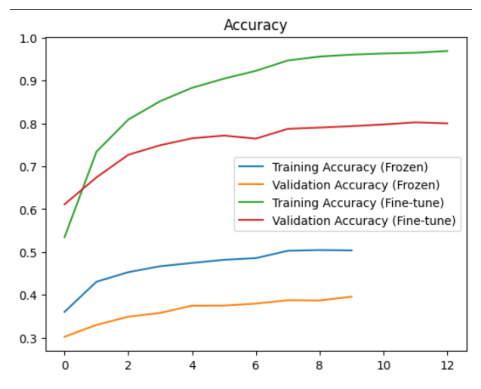

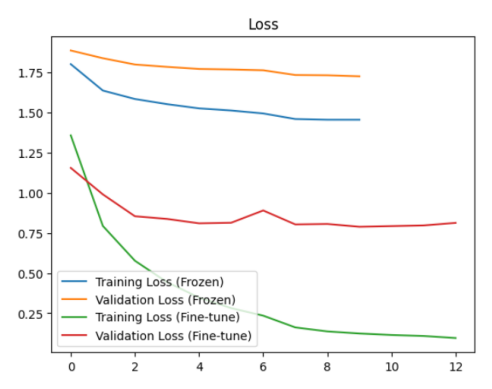

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Đường dẫn ảnh đã upload lên Kaggle
img_path = '/kaggle/input/acc-loss-image/acc_da_ml.png'  # Thay đúng đường dẫn ảnh

# Đọc và hiển thị ảnh
img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()
# Đường dẫn ảnh đã upload lên Kaggle
img_path = '/kaggle/input/acc-loss-image/loss_da_ml.png'  # Thay đúng đường dẫn ảnh

# Đọc và hiển thị ảnh
img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()


## Load model

In [5]:
# Tải mô hình đã lưu
model = load_model("car_classification_model_final.h5")

## Đánh giá

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


951/951 ━━━━━━━━━━━━━━━━━━━━ 639s 659ms/step - accuracy: 0.9899 - loss: 0.0387
238/238 ━━━━━━━━━━━━━━━━━━━━ 129s 541ms/step - accuracy: 0.7994 - loss: 0.8044
Training Accuracy: 98.94%
Validation Accuracy: 80.06%
238/238 ━━━━━━━━━━━━━━━━━━━━ 132s 529ms/step


<Figure size 1000x800 with 0 Axes>

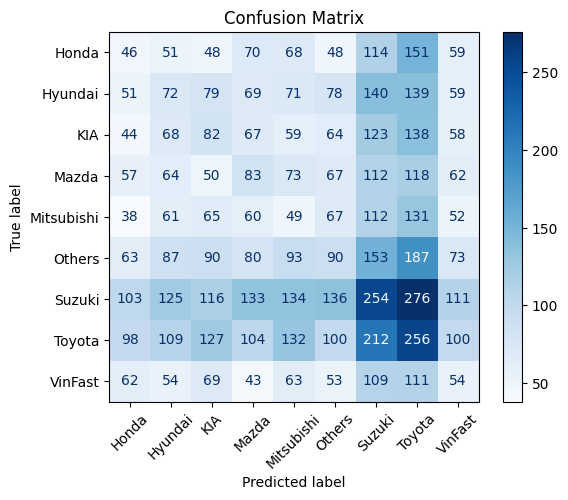

In [10]:


# Tính toán độ chính xác trên tập train và validation
train_loss, train_acc = model.evaluate(train_data)
val_loss, val_acc = model.evaluate(val_data)

print(f"Training Accuracy: {train_acc * 100:.2f}%") 
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

# Dự đoán trên tập validation
val_predictions = model.predict(val_data)
y_pred = np.argmax(val_predictions, axis=1)
y_true = val_data.classes

# Tính confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_labels = list(val_data.class_indices.keys())

# Hiển thị confusion matrix
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


## Test

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


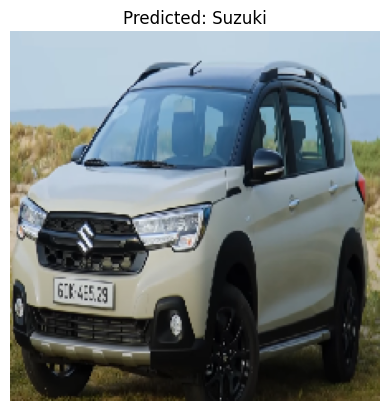

In [11]:

# Đường dẫn ảnh cần dự đoán
img_path = '/kaggle/input/testing/Suzuki.png'

# Tiền xử lý ảnh
def prepare_image(img_path, target_size=(300, 300)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_batch)
    return img, img_preprocessed

# Tải và xử lý ảnh
original_img, processed_img = prepare_image(img_path)

# Dự đoán nhãn
predictions = model.predict(processed_img)
predicted_class = np.argmax(predictions, axis=1)[0]
class_labels = list(val_data.class_indices.keys())

# Hiển thị ảnh gốc và nhãn dự đoán
plt.imshow(original_img)
plt.axis('off')
plt.title(f"Predicted: {class_labels[predicted_class]}")
plt.show()
